In [7]:
import os
import sys

if os.getcwd().endswith("notebooks"):
    os.chdir("..")
if os.getcwd() not in sys.path:
    sys.path.append(os.getcwd())

import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import PrecisionRecallDisplay
from src.data_loader import load_data
from src.evaluation import (
    evaluate_at_threshold,
    evaluate_thresholds,
    find_best_f1_threshold,
)
from src.model import build_xgboost
from src.preprocessing import split_and_scale_data

In [8]:
# Recreate the fixed split. Do not use the test set in this notebook yet.
df = load_data("data/creditcard.csv")
X_train, X_val, X_test, y_train, y_val, y_test, scaler = split_and_scale_data(
    df,
    test_size=0.20,
    validation_size=0.20,
    random_state=42,
)

model = build_xgboost()
model.fit(X_train, y_train)
y_val_probability = model.predict_proba(X_val)[:, 1]

Successfully loaded dataset


In [9]:
# Default threshold used by most classifiers.
default_metrics = evaluate_at_threshold(y_val, y_val_probability, threshold=0.50)
default_metrics

{'threshold': 0.5,
 'precision': 0.9080459770114943,
 'recall': 0.8404255319148937,
 'f1': 0.8729281767955801,
 'auprc': 0.8836795272698136,
 'true_negatives': 56643,
 'false_positives': 8,
 'false_negatives': 15,
 'true_positives': 79}

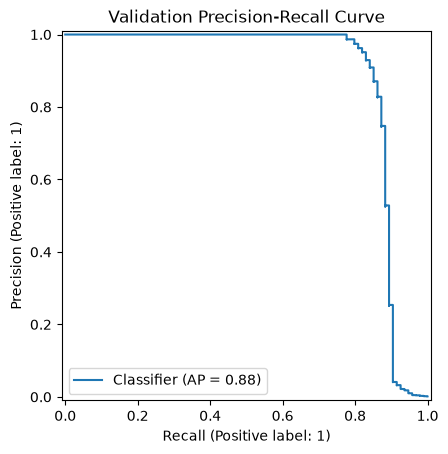

{'threshold': 0.9187861084938049,
 'precision': 0.9512195121951219,
 'recall': 0.8297872340425532,
 'f1': 0.8863636363631386}

In [10]:
PrecisionRecallDisplay.from_predictions(y_val, y_val_probability)
plt.title("Validation Precision-Recall Curve")
plt.show()

best_f1 = find_best_f1_threshold(y_val, y_val_probability)
best_f1

In [11]:
# Compare business-relevant thresholds. Lower threshold normally increases recall
# and false positives; choose one after reviewing this table.
threshold_results = evaluate_thresholds(
    y_val,
    y_val_probability,
    thresholds=np.arange(0.05, 0.55, 0.05),
).sort_values("threshold")
threshold_results

,threshold,precision,recall,f1,auprc,true_negatives,false_positives,false_negatives,true_positives
0,0.05,0.532051,0.882979,0.664000,0.88368,56578,73,11,83
1,0.10,0.734513,0.882979,0.801932,0.88368,56621,30,11,83
2,0.15,0.828283,0.872340,0.849741,0.88368,56634,17,12,82
3,0.20,0.843750,0.861702,0.852632,0.88368,56636,15,13,81
4,0.25,0.870968,0.861702,0.866310,0.88368,56639,12,13,81
5,0.30,0.869565,0.851064,0.860215,0.88368,56639,12,14,80
6,0.35,0.888889,0.851064,0.869565,0.88368,56641,10,14,80
7,0.40,0.898876,0.851064,0.874317,0.88368,56642,9,14,80
8,0.45,0.909091,0.851064,0.879121,0.88368,56643,8,14,80
9,0.50,0.908046,0.840426,0.872928,0.88368,56643,8,15,79


In [12]:
# Final evaluation: use the test set once after choosing the validation threshold.
final_threshold = best_f1["threshold"]
y_test_probability = model.predict_proba(X_test)[:, 1]

test_metrics = evaluate_at_threshold(
    y_test,
    y_test_probability,
    threshold=final_threshold,
)

test_metrics

{'threshold': 0.9187861084938049,
 'precision': 0.9855072463768116,
 'recall': 0.7157894736842105,
 'f1': 0.8292682926829268,
 'auprc': 0.8214193893831631,
 'true_negatives': 56650,
 'false_positives': 1,
 'false_negatives': 27,
 'true_positives': 68}

In [13]:
from pathlib import Path
from src.model import save_model

Path("models").mkdir(exist_ok=True)

artifact = {
    "model": model,
    "scaler": scaler,
    "threshold": float(final_threshold),
    "feature_names": list(X_train.columns),
}

save_model(artifact, "models/xgboost_fraud_detector.joblib")
print("Saved: models/xgboost_fraud_detector.joblib")

Saved: models/xgboost_fraud_detector.joblib
